# Amazon Sales Data Analysis

**Author:** Daniel Ürge  
**Date:** 2026 

## Goal
Analyze Amazon sales data to identify revenue trends, regional performance, order status distribution, and customer behaviour patterns.

## ETL Overview
- **Extract:** Raw CSV sales data (~68MB, ~128k records) - Amazon orders from India (March–June 2022).  Repository contains a 5% sample (6.4k records) for demonstration.
- **Transform:** Data cleaning, type conversions, feature engineering (Month, Weekday columns)
- **Load:** Aggregated datasets ready for analysis and visualization

## Tools Used
- Python 3
- Jupyter Notebook
- pandas, matplotlib, seaborn

## Key Questions
1. Which product categories generate the most revenue?
2. Which regions produce the highest sales?
3. What are the monthly sales trends?
4. What is the cancellation rate?
5. Is there a pattern in order timing by day of week?

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style — clean, professional look
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ACCENT = '#e47b2a'   # orange — Amazon brand colour
BASE   = '#2c3e50'   # dark blue-grey for secondary elements

In [2]:
# Load dataset — use low_memory=False to avoid dtype warnings on mixed-type columns
df = pd.read_csv("../data/amazon_sales.csv", low_memory=False)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 128,975 rows × 24 columns


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [3]:
# Quick overview of data types and missing values
df.info()
print("\nDescriptive statistics:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


## 2. Data Cleaning

Steps:
- Drop irrelevant/empty columns
- Parse dates and engineer time-based features
- Check for duplicates and missing values

In [4]:
# Drop the auto-generated empty trailing column present in this dataset
df = df.drop(columns=["Unnamed: 22"], errors="ignore")

# Check for duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# Missing values per column (only show columns with at least one NaN)
missing = df.isnull().sum()
print("\nMissing values:")
print(missing[missing > 0].sort_values(ascending=False))

Duplicate rows: 0

Missing values:
fulfilled-by        89698
promotion-ids       49153
currency             7795
Amount               7795
Courier Status       6872
ship-city              33
ship-state             33
ship-postal-code       33
ship-country           33
dtype: int64


In [5]:
# Parse date column and engineer time features used throughout the analysis
df["Date"]    = pd.to_datetime(df["Date"], format="%m-%d-%y")
df["Month"]   = df["Date"].dt.to_period("M")
df["Weekday"] = df["Date"].dt.day_name()

# Normalise state/city names to uppercase to avoid duplicates caused by casing (e.g. 'delhi' vs 'DELHI')
df["ship-state"] = df["ship-state"].str.upper().str.strip()
df["ship-city"] = df["ship-city"].str.upper().str.strip()

print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
print("Unique states:", df["ship-state"].nunique())
print("Unique cities:", df["ship-city"].nunique())

Date range: 2022-03-31 → 2022-06-29
Unique states: 47
Unique cities: 7297


## 3. Data Analysis

### 3.1 Revenue by Product Category

In [6]:
category_revenue = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
print(category_revenue.apply(lambda x: f"₹{x:,.0f}"))

Category
Set              ₹39,204,124
kurta            ₹21,299,547
Western Dress    ₹11,216,073
Top               ₹5,347,792
Ethnic Dress        ₹791,218
Blouse              ₹458,408
Bottom              ₹150,668
Saree               ₹123,934
Dupatta                 ₹915
Name: Amount, dtype: object


### 3.2 Regional Performance (Top 10 States)

In [7]:
state_revenue = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)
print(state_revenue.apply(lambda x: f"₹{x:,.0f}"))

ship-state
MAHARASHTRA       ₹13,335,534
KARNATAKA         ₹10,481,114
TELANGANA          ₹6,916,616
UTTAR PRADESH      ₹6,816,642
TAMIL NADU         ₹6,515,650
DELHI              ₹4,346,412
KERALA             ₹3,830,228
WEST BENGAL        ₹3,507,880
ANDHRA PRADESH     ₹3,219,832
HARYANA            ₹2,882,093
Name: Amount, dtype: object


### 3.3 City Revenue (Top 5 Cities)

In [8]:
city_revenue = df.groupby("ship-city")["Amount"].sum().sort_values(ascending=False).head(5)
print(city_revenue.apply(lambda x: f"₹{x:,.0f}"))

ship-city
BENGALURU    ₹7,257,749
HYDERABAD    ₹5,599,822
MUMBAI       ₹4,293,210
NEW DELHI    ₹3,952,690
CHENNAI      ₹3,606,918
Name: Amount, dtype: object


### 3.4 Monthly Revenue Trend

In [9]:
monthly_sales = df.groupby("Month")["Amount"].sum()
print(monthly_sales.apply(lambda x: f"₹{x:,.0f}"))

Month
2022-03       ₹101,684
2022-04    ₹28,838,708
2022-05    ₹26,226,477
2022-06    ₹23,425,809
Freq: M, Name: Amount, dtype: object


### 3.5 Order Status & Cancellation Rate

In [10]:
status_counts = df["Status"].value_counts()
print(status_counts)

# Cancellation rate — key fulfilment quality metric
cancel_rate = (df["Status"] == "Cancelled").mean()
print(f"\nCancellation rate: {cancel_rate:.1%}")

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

Cancellation rate: 14.2%


### 3.6 Order Activity by Weekday

In [11]:
# Sort weekdays in calendar order for readability
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = (
    df.groupby("Weekday")["Amount"]
    .sum()
    .reindex(weekday_order)
)
print(weekday_sales.apply(lambda x: f"₹{x:,.0f}"))

Weekday
Monday       ₹11,318,441
Tuesday      ₹11,491,626
Wednesday    ₹11,249,823
Thursday     ₹10,358,594
Friday       ₹10,805,395
Saturday     ₹11,339,358
Sunday       ₹12,029,441
Name: Amount, dtype: object


## 4. Visualizations

### 4.1 Monthly Revenue Trend
Line chart showing total revenue per month. Useful for spotting seasonality and growth patterns.

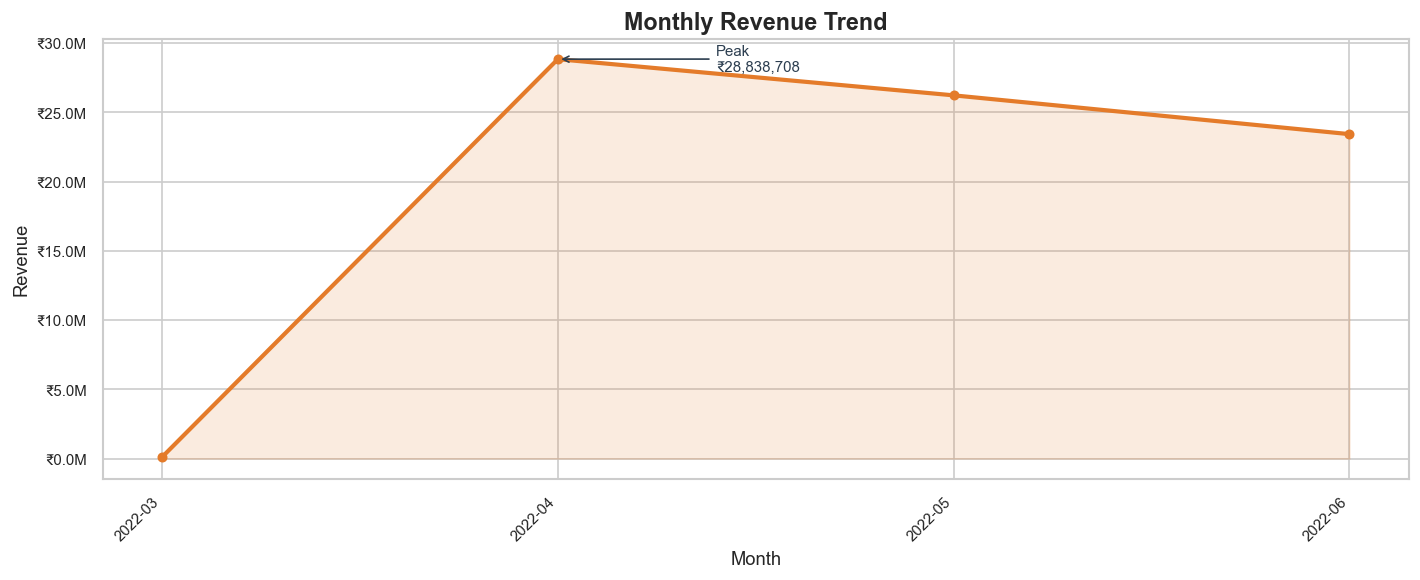

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(monthly_sales))
ax.fill_between(x, monthly_sales.values, alpha=0.15, color=ACCENT)
ax.plot(x, monthly_sales.values, color=ACCENT, linewidth=2.5, marker='o', markersize=5)

# Mark the peak month
peak_idx = monthly_sales.values.argmax()
ax.annotate(
    f'Peak\n₹{monthly_sales.values[peak_idx]:,.0f}',
    xy=(peak_idx, monthly_sales.values[peak_idx]),
    xytext=(peak_idx + 0.4, monthly_sales.values[peak_idx] * 0.97),
    arrowprops=dict(arrowstyle='->', color=BASE),
    fontsize=9, color=BASE
)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in monthly_sales.index], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1e6:.1f}M'))
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('../images/revenue_trend.png', dpi=150)
plt.show()

### 4.2 Top 10 States by Revenue

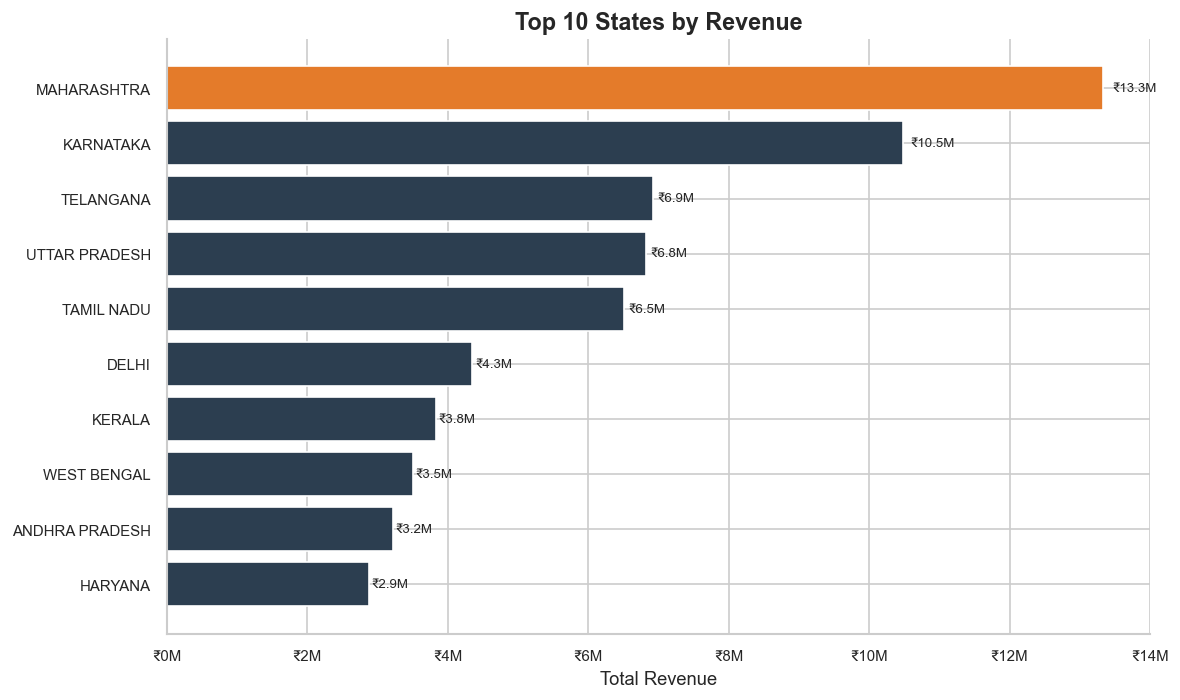

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = [ACCENT if i == 0 else BASE for i in range(len(state_revenue))]
bars = ax.barh(state_revenue.index[::-1], state_revenue.values[::-1], color=colors[::-1])

# Add value labels at end of each bar
for bar in bars:
    w = bar.get_width()
    ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
            f'₹{w/1e6:.1f}M', va='center', fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1e6:.0f}M'))
ax.set_title('Top 10 States by Revenue')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/top_states.png', dpi=150)
plt.show()

### 4.3 Top 5 Cities by Revenue

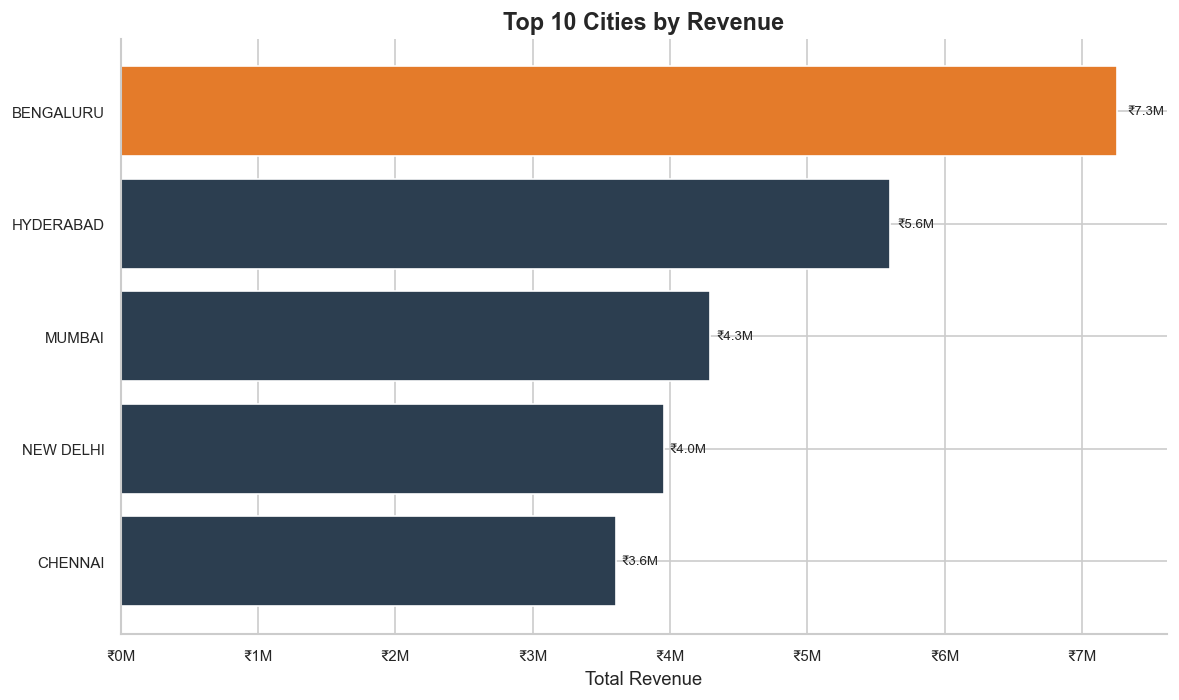

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = [ACCENT if i == 0 else BASE for i in range(len(city_revenue))]
bars = ax.barh(city_revenue.index[::-1], city_revenue.values[::-1], color=colors[::-1])

for bar in bars:
    w = bar.get_width()
    ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
            f'₹{w/1e6:.1f}M', va='center', fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1e6:.0f}M'))
ax.set_title('Top 5 Cities by Revenue')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/top_cities.png', dpi=150)
plt.show()

### 4.4 Revenue by Product Category

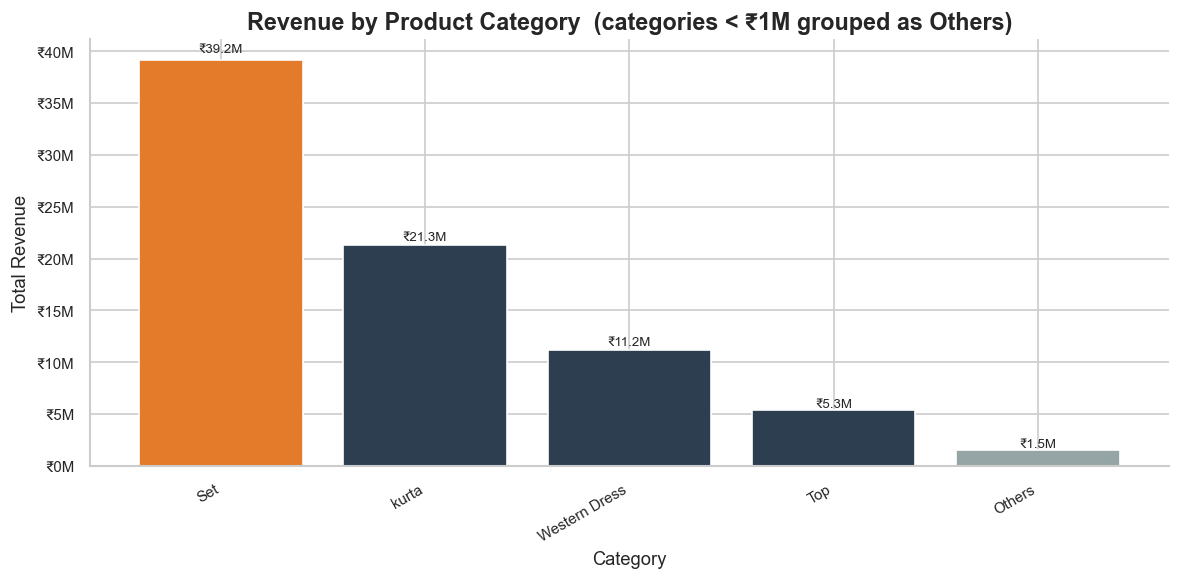

In [15]:
# Threshold: categories below ₹1M grouped as "Others"
threshold = 1_000_000

main = category_revenue[category_revenue >= threshold]
others_sum = category_revenue[category_revenue < threshold].sum()

if others_sum > 0:
    import pandas as pd
    main = pd.concat([main, pd.Series({'Others': others_sum})])

palette = [ACCENT if i == 0 else '#95a5a6' if cat == 'Others' else BASE 
           for i, cat in enumerate(main.index)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(main.index, main.values, color=palette)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
            f'₹{h/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1e6:.0f}M'))
ax.set_title('Revenue by Product Category  (categories < ₹1M grouped as Others)')
ax.set_xlabel('Category')
ax.set_ylabel('Total Revenue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../images/category_revenue.png', dpi=150)
plt.show()

### 4.5 Order Status Distribution

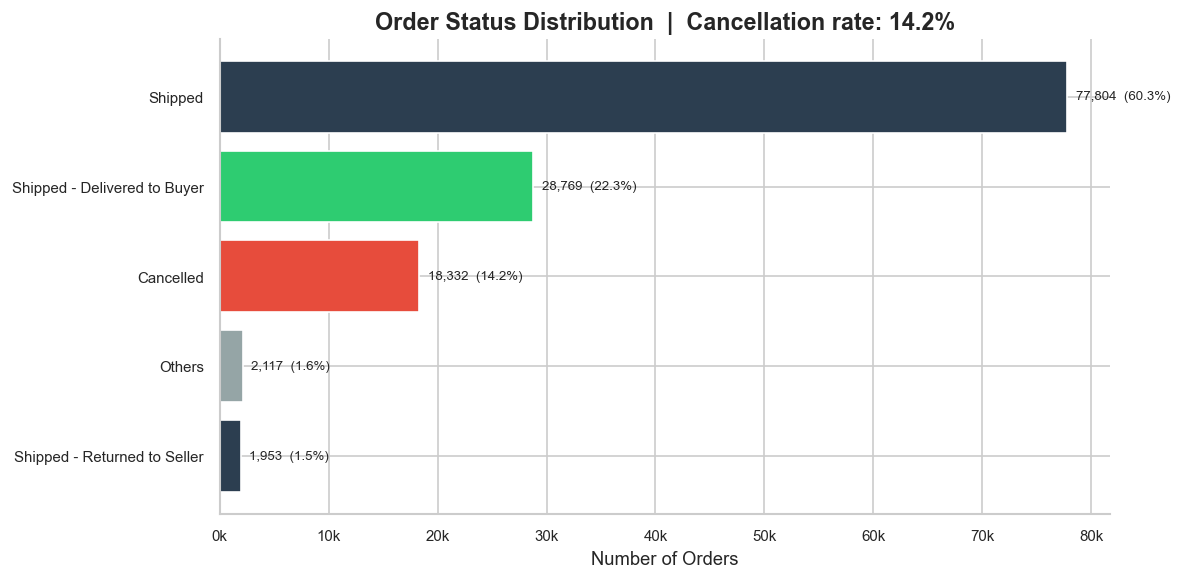

In [19]:
# Threshold: statuses below 1% of total orders grouped as "Others"
total_orders = status_counts.sum()
threshold_pct = 0.01  # 1%

main_status = status_counts[status_counts / total_orders >= threshold_pct]
others_sum = status_counts[status_counts / total_orders < threshold_pct].sum()

if others_sum > 0:
    main_status = pd.concat([main_status, pd.Series({'Others': others_sum})])

main_status = main_status.sort_values(ascending=True)

bar_colors = [
    '#e74c3c' if s == 'Cancelled'
    else '#2ecc71' if 'Delivered' in s
    else '#95a5a6' if s == 'Others'
    else BASE
    for s in main_status.index
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(main_status.index, main_status.values, color=bar_colors)

for bar in bars:
    w = bar.get_width()
    pct = w / total_orders * 100
    ax.text(w + main_status.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{w:,}  ({pct:.1f}%)', va='center', fontsize=8)

ax.set_title(f'Order Status Distribution  |  Cancellation rate: {cancel_rate:.1%}')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/order_status.png', dpi=150)
plt.show()

### 4.6 Revenue by Weekday
Weekday differences are relatively small (±16%), no strong pattern identified.

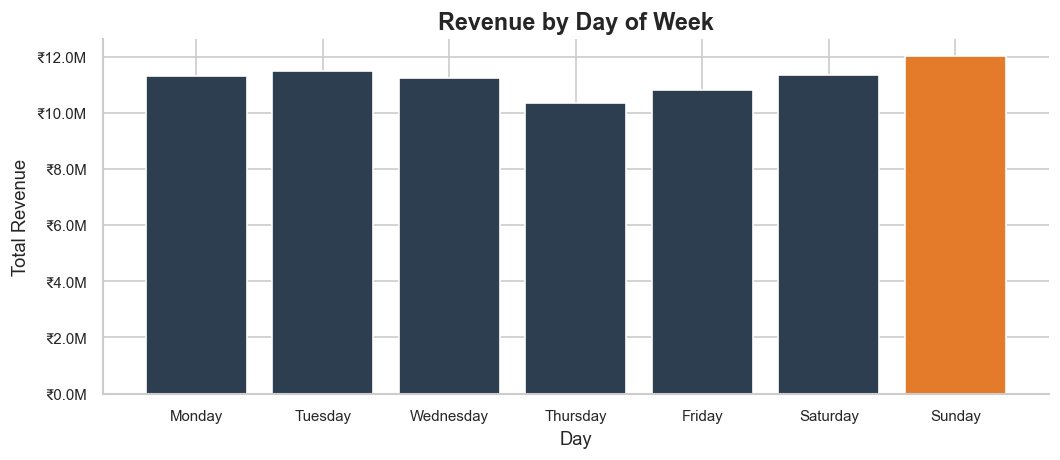

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))

bar_colors = [ACCENT if d == 'Sunday' else BASE for d in weekday_order]
ax.bar(weekday_order, weekday_sales.values, color=bar_colors)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1e6:.1f}M'))
ax.set_title('Revenue by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Total Revenue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 4.7 Revenue Heatmap — Category × Month
Shows which categories drive revenue in each month — useful for seasonal inventory planning.

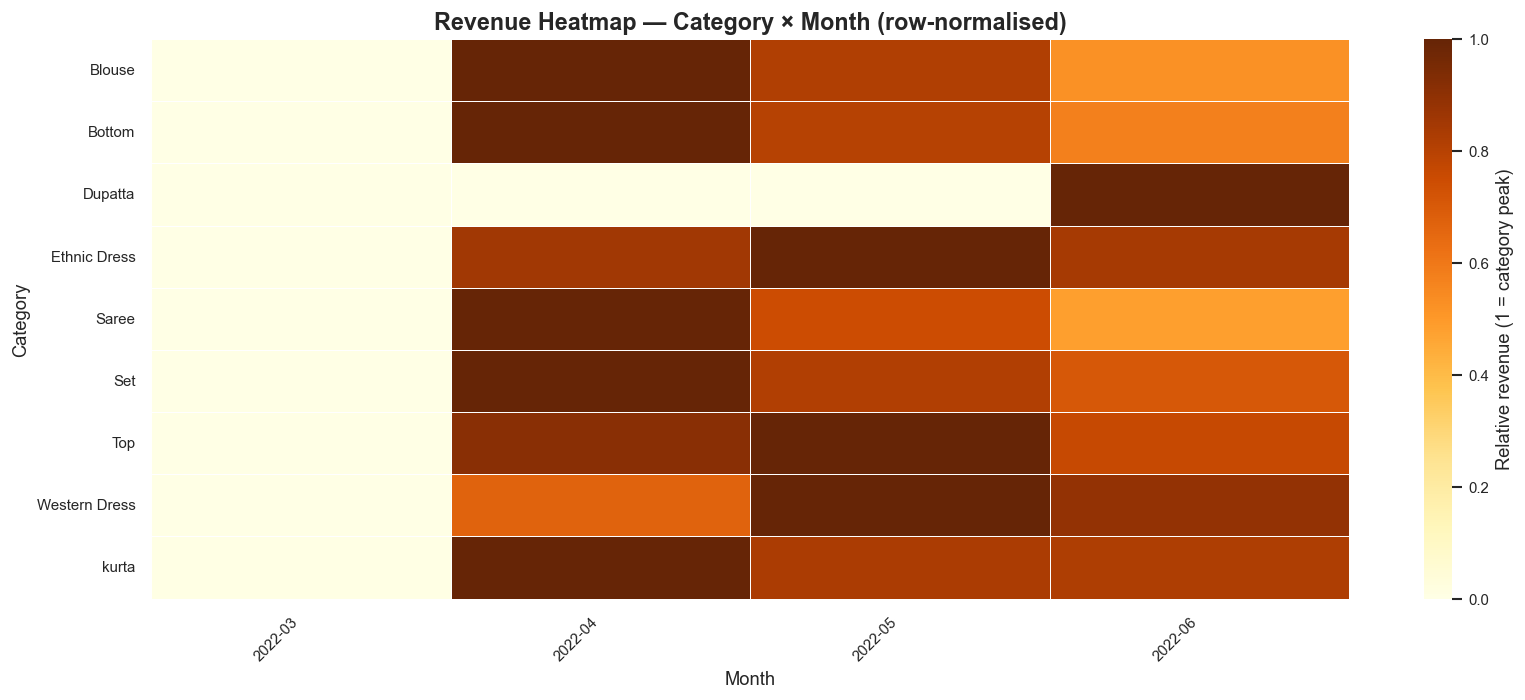

In [18]:
pivot = df.pivot_table(
    index='Category', columns='Month', values='Amount', aggfunc='sum'
).fillna(0)

# Normalise rows so each category is comparable regardless of absolute scale
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_norm,
    linewidths=0.4,
    cmap='YlOrBr',
    ax=ax,
    cbar_kws={'label': 'Relative revenue (1 = category peak)'}
)
ax.set_title('Revenue Heatmap — Category × Month (row-normalised)')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Business Insights

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | **Set** category dominates revenue : ₹39.2M out of a total ₹78.6M = 49.8% of total revenue  | Bundled products drive sales — prioritise inventory here |
| 2 | The #1 state is **Maharashtra**, but the #1 city is **Bengaluru** (**Karnataka**) — **Karnataka** is strong due to revenue concentration in a single city, while **Maharashtra’s** revenue is distributed across multiple cities. | Focus marketing spend and logistics capacity on these regions |
| 3 | Sales **peaked in April 2022** | Likely seasonal effect — worth investigating promotional calendar |
| 4 | **Cancellation rate: 14.2%**, above e-commerce average of 5–10% — see chart | May indicate fulfiment delays or misleading product listings; needs further root-cause analysis |

## 6. What I Would Do Next
This analysis is based on ~3 months of data which limits some conclusions. 
Given more time or data, I would explore:

- **Cancellation root cause** — 14.2% cancellation rate is above e-commerce average. 
  I'd investigate whether cancellations are concentrated in specific categories, 
  states, or fulfilment methods (Merchant vs Amazon).
- **Longer time range** — 3 months isn't enough to confirm seasonality. 
  With full-year data I could tell whether the April peak repeats annually 
  or was a one-off.
- **City vs State mismatch** — Bengaluru (#1 city) sits in Karnataka (#2 state), 
  suggesting Karnataka's revenue is concentrated in one city while Maharashtra 
  is more spread out. Worth validating with a city-level breakdown per state.